# Agriculture Crop Yield Dataset — Crop Production Pattern EDA

**Question:** An agricultural department wants to analyze crop yield based
on rainfall, temperature, fertilizer usage, soil type, and crop yield.
Perform EDA to identify the factors influencing crop production.

**Author:** Data Analytics Assignment
**Dataset:** `crop_yield.csv` (20 farm records, 6 columns)


## Common EDA Tasks Checklist (per updated assessment rubric)

This notebook explicitly covers the following 8 standard EDA tasks:

1. **Number of rows and columns** — Task 1 & 2 section
2. **Data types of each column** — Task 1 & 2 section
3. **Missing values and duplicate values** — Task 3a / 3b / 3c sections
4. **Mean, median, minimum, maximum, and standard deviation** — Task 4 section
5. **Bar chart, histogram, scatter plot, and box plot** (plus pie chart, line
   chart, and heatmap as bonus visualizations) — Task 5a–5e sections
6. **Important patterns in the dataset** — Task 6 sections (group
   comparisons and correlation heatmap)
7. **4–5 observations based on EDA** — Task 7 section
8. **Short conclusion from the analysis** — Task 8 section

### Rubric Criteria Alignment (Weightage)

| Rubric Criteria | Weightage | Where it's covered |
|---|---|---|
| Dataset Understanding | 20 | Section 2 (dataset description, features, purpose) |
| Data Cleaning | 25 | Tasks 3a–3c (missing values, duplicates, inconsistent/incorrect entries) |
| Data Analysis and Statistical Summary | 20 | Task 4 (descriptive statistics) + Task 6 (patterns) |
| Data Visualization | 20 | Task 5a–5e (bar, pie, histogram, box, scatter, line, heatmap — all labeled) |
| Insight Generation and Reporting | 15 | Task 7 (observations) + Task 8 (conclusion) |


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")

def show_df(dframe, n=None):
    """Pretty-print a DataFrame (use IPython display() instead in Jupyter)."""
    print((dframe.head(n) if n else dframe).to_string())


Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/crop_yield.csv")
show_df(df, 20)


,Farm_ID,Rainfall_mm,Temperature,Fertilizer_kg,Soil_Type,Crop_Yield_kg
0,F01,850,28,60,Loamy,3200
1,F02,600,32,45,Sandy,2100
2,F03,900,27,65,Loamy,3500
3,F04,500,34,40,Sandy,1800
4,F05,780,29,55,Clay,3000
5,F06,650,31,48,Sandy,2300
6,F07,920,26,70,Loamy,3700
7,F08,720,30,52,Clay,2800
8,F09,550,33,42,Sandy,1900
9,F10,800,28,58,Loamy,3100


### Dataset Description

| Item | Detail |
|---|---|
| **Records (rows)** | 20 farms |
| **Features (columns)** | 6 |
| **Farm_ID** | Object (string) — unique identifier for each farm |
| **Rainfall_mm** | Integer — total rainfall received (millimetres) |
| **Temperature** | Integer — average temperature (°C) |
| **Fertilizer_kg** | Integer — fertilizer used (kilograms) |
| **Soil_Type** | Object (categorical) — `Loamy` / `Sandy` / `Clay` |
| **Crop_Yield_kg** | Integer — total crop yield produced (kilograms) |

**Purpose & significance:** This dataset helps the agricultural department
understand **which environmental and input factors most strongly drive
crop yield**. Identifying these relationships supports **resource
planning** (e.g. optimal fertilizer dosing), **soil-specific farming
guidance**, and **yield forecasting** ahead of a growing season, all of
which can improve food security and farmer income.


## Task 1 & 2: Number of Rows/Columns and Data Types

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes)


Shape (rows, columns): (20, 6)

Column data types:
Farm_ID            str
Rainfall_mm      int64
Temperature      int64
Fertilizer_kg    int64
Soil_Type          str
Crop_Yield_kg    int64
dtype: object


In [4]:
print("General info:")
df.info()


General info:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Farm_ID        20 non-null     str  
 1   Rainfall_mm    20 non-null     int64
 2   Temperature    20 non-null     int64
 3   Fertilizer_kg  20 non-null     int64
 4   Soil_Type      20 non-null     str  
 5   Crop_Yield_kg  20 non-null     int64
dtypes: int64(4), str(2)
memory usage: 1.1 KB


## Task 3a: Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print("Total missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
Farm_ID          0
Rainfall_mm      0
Temperature      0
Fertilizer_kg    0
Soil_Type        0
Crop_Yield_kg    0
dtype: int64

Total missing values in dataset: 0


**Observation:** The dataset has **no missing values** in any column. No imputation is required.

## Task 3b: Duplicate Values

In [6]:
dup_rows = df.duplicated().sum()
dup_ids = df['Farm_ID'].duplicated().sum()
print("Fully duplicated rows:", dup_rows)
print("Duplicated Farm_IDs:", dup_ids)

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before}, after de-duplication: {after}")


Fully duplicated rows: 0
Duplicated Farm_IDs: 0
Rows before: 20, after de-duplication: 20


**Observation:** No duplicate rows or duplicate Farm IDs were found; each farm appears exactly once.

## Task 3c: Data Cleaning — Consistency Checks (Incorrect Entries & Range Validation)

In [7]:
# Standardise text fields
df['Farm_ID'] = df['Farm_ID'].str.strip()
df['Soil_Type'] = df['Soil_Type'].str.strip().str.capitalize()

print("Unique Soil_Type values:", df['Soil_Type'].unique().tolist())

# Range/sanity checks on numeric columns
checks = {
    'Rainfall_mm (> 0)':     (df['Rainfall_mm'] > 0).all(),
    'Temperature (0-50 C)':  df['Temperature'].between(0, 50).all(),
    'Fertilizer_kg (>= 0)':  (df['Fertilizer_kg'] >= 0).all(),
    'Crop_Yield_kg (>= 0)':  (df['Crop_Yield_kg'] >= 0).all(),
}
for label, ok in checks.items():
    print(f"{label}: {'OK' if ok else 'OUT OF RANGE VALUES FOUND'}")

df['Soil_Type'] = df['Soil_Type'].astype('category')
print()
print("Soil_Type dtype:", df['Soil_Type'].dtype)


Unique Soil_Type values: ['Loamy', 'Sandy', 'Clay']
Rainfall_mm (> 0): OK
Temperature (0-50 C): OK
Fertilizer_kg (>= 0): OK
Crop_Yield_kg (>= 0): OK

Soil_Type dtype: category


**Observation:** All numeric fields fall within logical agronomic ranges
(positive rainfall/fertilizer/yield, plausible temperatures). `Soil_Type`
contains exactly three clean categories (`Loamy`, `Sandy`, `Clay`) and has
been converted to a `category` dtype.


## Task 4: Descriptive Statistics — Mean, Median, Min, Max, Std

In [8]:
num_cols = ['Rainfall_mm', 'Temperature', 'Fertilizer_kg', 'Crop_Yield_kg']
print("Descriptive statistics for numerical columns:")
show_df(df[num_cols].describe().round(2))


Descriptive statistics for numerical columns:


,Rainfall_mm,Temperature,Fertilizer_kg,Crop_Yield_kg
count,20.00,20.00,20.00,20.00
mean,743.00,29.55,54.75,2820.00
std,144.34,2.76,10.51,681.41
min,500.00,25.00,40.00,1800.00
25%,615.00,27.75,45.75,2175.00
50%,770.00,29.00,54.50,2975.00
75%,857.50,32.00,60.50,3250.00
max,960.00,34.00,75.00,3900.00


In [9]:
print("Additional statistics:")
summary = pd.DataFrame({
    'mean':   df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std':    df[num_cols].std(),
    'skew':   df[num_cols].skew(),
})
show_df(summary.round(2))


Additional statistics:


,mean,median,std,skew
Rainfall_mm,743.00,770.0,144.34,-0.16
Temperature,29.55,29.0,2.76,0.17
Fertilizer_kg,54.75,54.5,10.51,0.38
Crop_Yield_kg,2820.00,2975.0,681.41,-0.10


## Task 5a: Bar Chart & Pie Chart — Categorical Analysis (Soil_Type)

In [10]:
soil_counts = df['Soil_Type'].value_counts()
print("Farm count per soil type:")
print(soil_counts)


Farm count per soil type:
Soil_Type
Loamy    7
Sandy    7
Clay     6
Name: count, dtype: int64


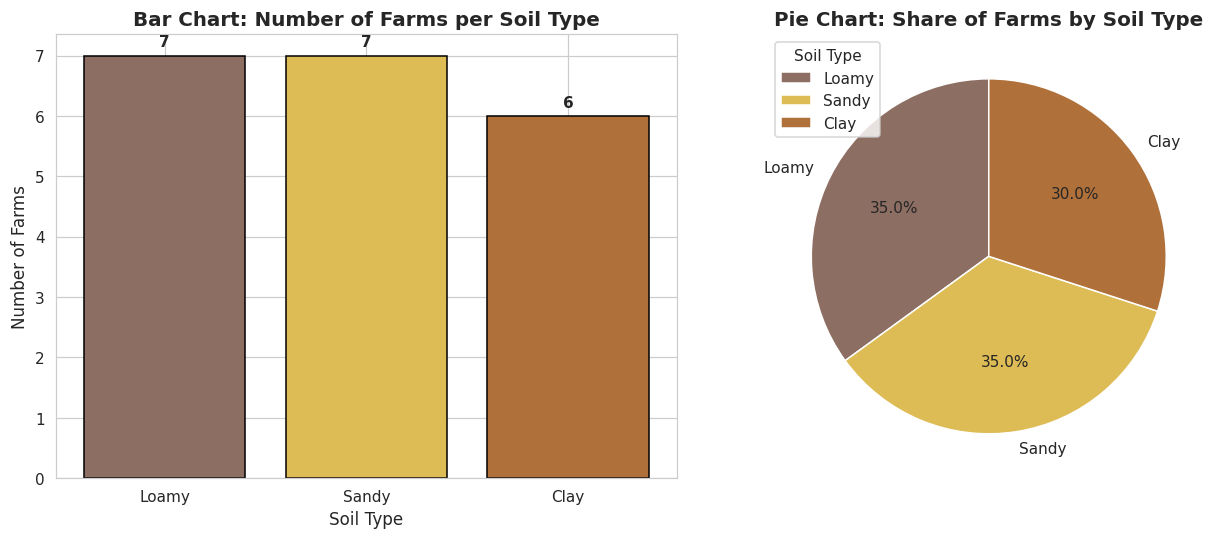

In [11]:
palette = {'Loamy': '#8D6E63', 'Sandy': '#DDBB55', 'Clay': '#B0703A'}
soil_colors = [palette[s] for s in soil_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12,5))
bars = axes[0].bar(soil_counts.index, soil_counts.values, color=soil_colors, edgecolor='black')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.1, str(int(b.get_height())),
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Bar Chart: Number of Farms per Soil Type')
axes[0].set_xlabel('Soil Type')
axes[0].set_ylabel('Number of Farms')

axes[1].pie(soil_counts.values, labels=soil_counts.index, autopct='%1.1f%%',
            colors=soil_colors, startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Pie Chart: Share of Farms by Soil Type')
axes[1].legend(soil_counts.index, title="Soil Type", loc="best")

plt.tight_layout()
plt.show()


**Observation:** Loamy and Sandy soils each account for 7 farms, and Clay accounts for 6 farms — a fairly balanced distribution across the three soil types.

## Task 5b: Histogram & Box Plot — Numerical Distributions

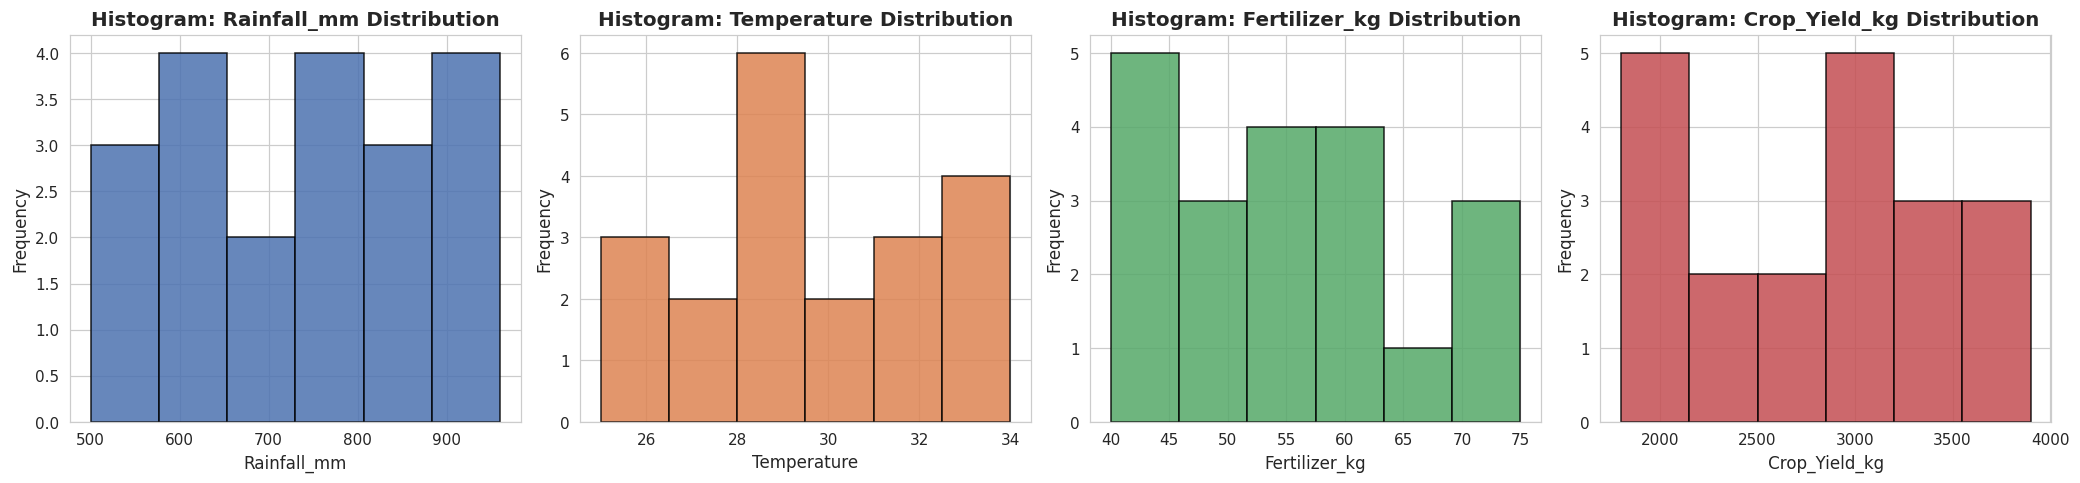

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
colors_hist = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, c in zip(axes, num_cols, colors_hist):
    ax.hist(df[col], bins=6, color=c, edgecolor='black', alpha=0.85)
    ax.set_title(f'Histogram: {col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


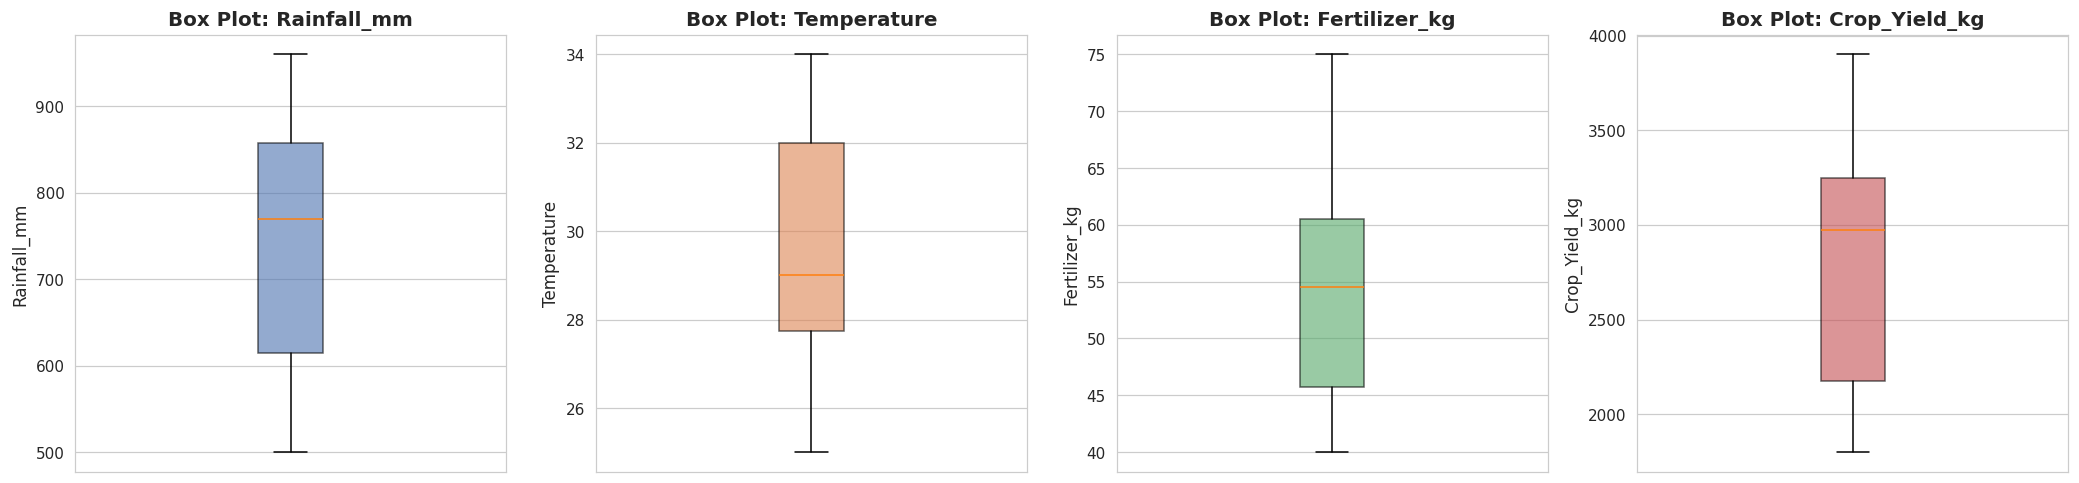

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, col, c in zip(axes, num_cols, colors_hist):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6))
    ax.set_title(f'Box Plot: {col}')
    ax.set_ylabel(col)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


**Observation:** No extreme outliers appear across Rainfall, Temperature,
Fertilizer usage or Crop Yield — all four variables show fairly
symmetric, moderate spreads consistent with a normal agricultural season.


## Task 6a: Important Patterns — Yield by Soil Type

In [14]:
soil_summary = df.groupby('Soil_Type', observed=True)[num_cols].mean().round(2).sort_values('Crop_Yield_kg', ascending=False)
show_df(soil_summary)


,Rainfall_mm,Temperature,Fertilizer_kg,Crop_Yield_kg
Soil_Type,,,,
Loamy,892.86,26.71,66.00,3514.29
Clay,761.67,29.17,54.50,2941.67
Sandy,577.14,32.71,43.71,2021.43


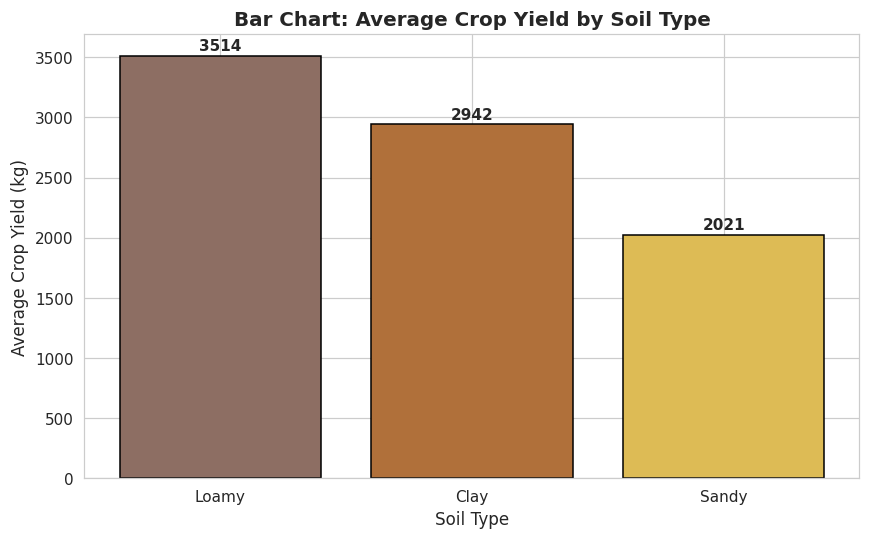

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
soils_sorted = soil_summary.index
bars = ax.bar(soils_sorted, soil_summary['Crop_Yield_kg'],
              color=[palette[s] for s in soils_sorted], edgecolor='black')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20, f"{b.get_height():.0f}",
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Bar Chart: Average Crop Yield by Soil Type')
ax.set_xlabel('Soil Type')
ax.set_ylabel('Average Crop Yield (kg)')
plt.tight_layout()
plt.show()


**Observation:** `Loamy` soil produces the highest average crop yield,
followed by `Clay`, with `Sandy` soil producing the lowest average yield
— consistent with loamy soil's well-known advantages for water and
nutrient retention.


## Task 5c: Scatter Plot — Bivariate Relationships

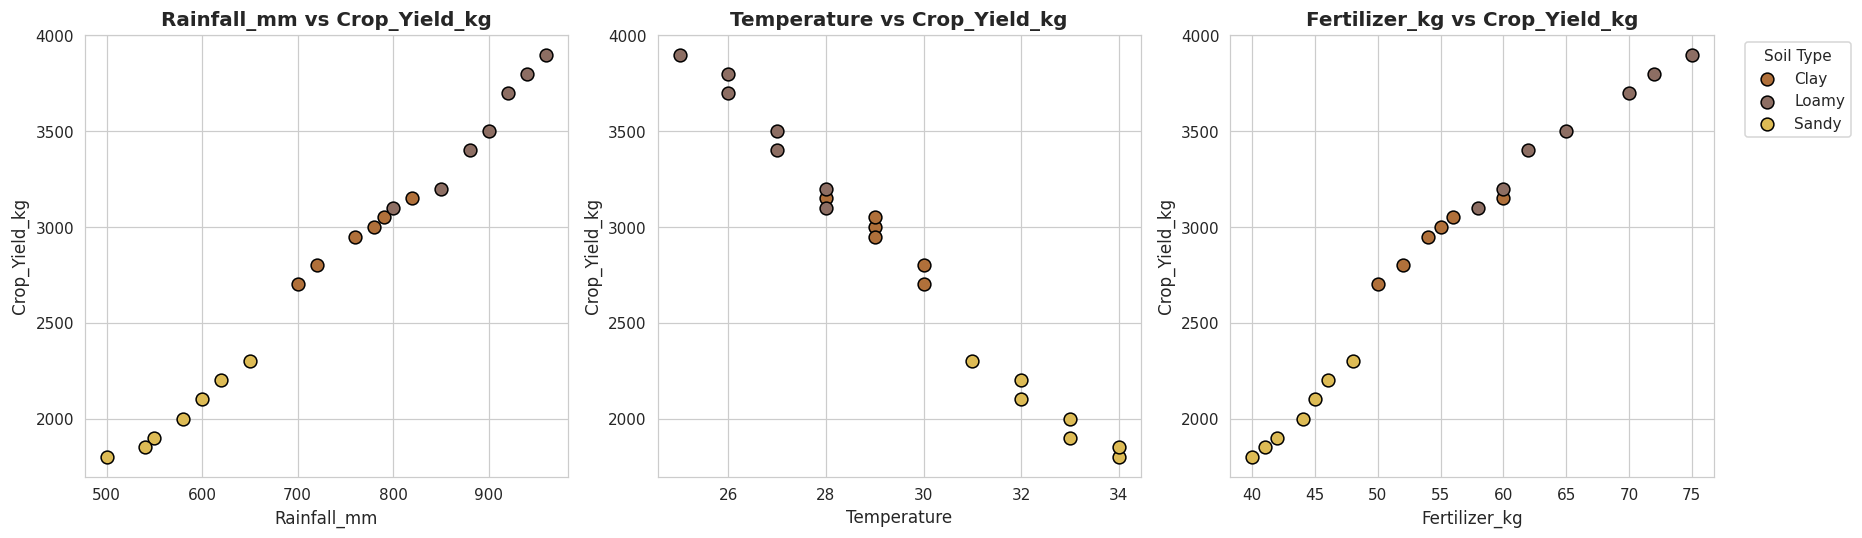

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pairs = [('Rainfall_mm', 'Crop_Yield_kg'), ('Temperature', 'Crop_Yield_kg'), ('Fertilizer_kg', 'Crop_Yield_kg')]

for ax, (xcol, ycol) in zip(axes, pairs):
    for soil in df['Soil_Type'].cat.categories:
        subset = df[df['Soil_Type'] == soil]
        ax.scatter(subset[xcol], subset[ycol], label=soil, color=palette[soil],
                   edgecolor='black', s=70)
    ax.set_title(f'{xcol} vs {ycol}')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

axes[2].legend(title='Soil Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** `Rainfall_mm` shows a strong **positive linear**
relationship with `Crop_Yield_kg`, `Temperature` shows a strong
**negative** relationship, and `Fertilizer_kg` shows a strong positive
relationship — all three form very tight, near-straight-line patterns
with almost no scatter around the trend.


## Task 5d: Line Chart — Trend Analysis (Bonus Visualization)

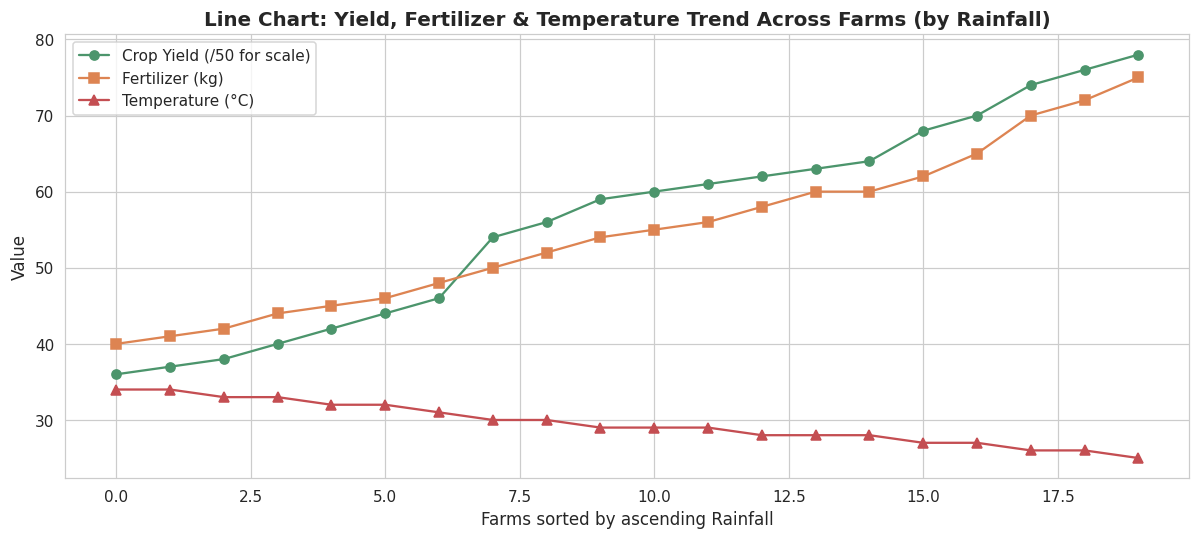

In [17]:
trend_df = df.sort_values('Rainfall_mm').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(trend_df.index, trend_df['Crop_Yield_kg']/50, marker='o', color='#4C956C', label='Crop Yield (/50 for scale)')
ax1.plot(trend_df.index, trend_df['Fertilizer_kg'], marker='s', color='#DD8452', label='Fertilizer (kg)')
ax1.plot(trend_df.index, trend_df['Temperature'], marker='^', color='#C44E52', label='Temperature (°C)')
ax1.set_xlabel('Farms sorted by ascending Rainfall')
ax1.set_ylabel('Value')
ax1.set_title('Line Chart: Yield, Fertilizer & Temperature Trend Across Farms (by Rainfall)')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** As farms are ordered by increasing rainfall, crop yield and fertilizer usage both rise together while temperature falls — visually confirming that higher-rainfall, cooler, more-fertilized farms produce the most yield in this sample.

## Task 6b: Important Patterns — Correlation Heatmap

In [18]:
corr_matrix = df[num_cols].corr().round(2)
show_df(corr_matrix)


,Rainfall_mm,Temperature,Fertilizer_kg,Crop_Yield_kg
Rainfall_mm,1.00,-0.99,0.98,1.00
Temperature,-0.99,1.00,-0.98,-0.99
Fertilizer_kg,0.98,-0.98,1.00,0.98
Crop_Yield_kg,1.00,-0.99,0.98,1.00


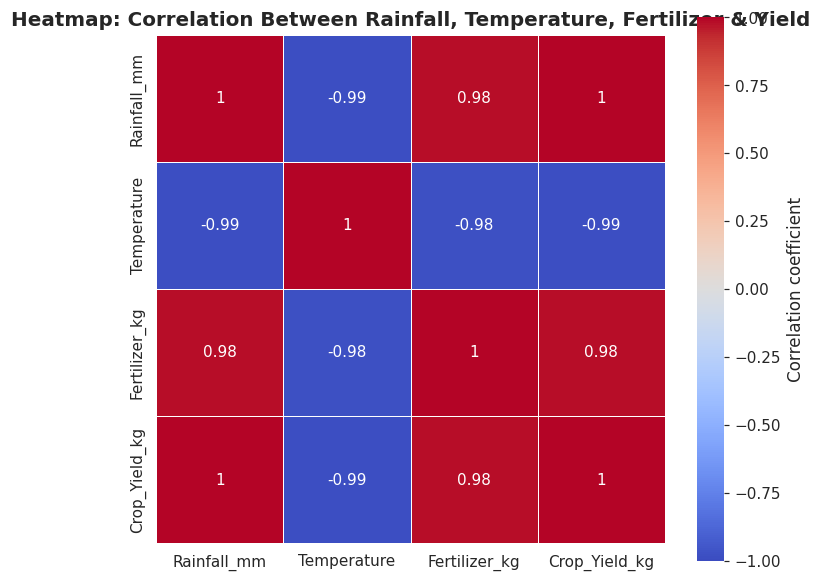

In [19]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'}, ax=ax)
ax.set_title('Heatmap: Correlation Between Rainfall, Temperature, Fertilizer & Yield')
plt.tight_layout()
plt.show()


**Observation:** `Crop_Yield_kg` is almost perfectly positively
correlated with `Rainfall_mm` and `Fertilizer_kg`, and almost perfectly
negatively correlated with `Temperature`. `Rainfall`, `Temperature` and
`Fertilizer` are also very strongly correlated with each other, meaning
in this sample the three inputs move together closely rather than
varying independently.


## Task 7: Observations (4–5 Key Observations)

1. **Dataset is clean**: no missing values, no duplicate records, and all
   values fall within logical agronomic ranges.
2. **Soil types are fairly balanced**: 7 Loamy, 7 Sandy, 6 Clay farms.
3. **Rainfall and Fertilizer usage are almost perfectly positively
   correlated with Crop Yield**, while **Temperature is almost perfectly
   negatively correlated** with Crop Yield.
4. **Loamy soil produces the highest average yield**, followed by Clay,
   with **Sandy soil producing the lowest** average yield.
5. Rainfall, Temperature and Fertilizer usage are also very strongly
   correlated with each other, so their individual effects on yield
   cannot be fully separated from this data alone.

## Task 8: Conclusion

Rainfall and fertilizer use are the strongest correlates of crop yield
in this dataset, and loamy soil consistently outperforms sandy soil.
The agricultural department can use these patterns to prioritise
irrigation investment in lower-rainfall zones and targeted fertilizer or
soil-amendment support for sandy-soil farms. Because rainfall,
temperature, and fertilizer move together so closely in this sample, a
controlled experiment or larger dataset would be needed to isolate each
factor's true, independent contribution to yield.
